# Step 1: Loading the NY Housing Data
In this section, we import the necessary libraries (**Pandas** for data manipulation and **Matplotlib** for visualization). We also load the CSV dataset and clean up the column names so Python can read them easily.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
data = pd.read_csv('NY-House-Dataset.csv')
data.head()

,BROKERTITLE,TYPE,PRICE,BEDS,BATH,PROPERTYSQFT,ADDRESS,STATE,MAIN_ADDRESS,ADMINISTRATIVE_AREA_LEVEL_2,LOCALITY,SUBLOCALITY,STREET_NAME,LONG_NAME,FORMATTED_ADDRESS,LATITUDE,LONGITUDE
0,Brokered by Douglas Elliman -111 Fifth Ave,Condo for sale,315000,2,2.000000,1400.0,2 E 55th St Unit 803,"New York, NY 10022","2 E 55th St Unit 803New York, NY 10022",New York County,New York,Manhattan,East 55th Street,Regis Residence,"Regis Residence, 2 E 55th St #803, New York, N...",40.761255,-73.974483
1,Brokered by Serhant,Condo for sale,195000000,7,10.000000,17545.0,Central Park Tower Penthouse-217 W 57th New Yo...,"New York, NY 10019",Central Park Tower Penthouse-217 W 57th New Yo...,United States,New York,New York County,New York,West 57th Street,"217 W 57th St, New York, NY 10019, USA",40.766393,-73.980991
2,Brokered by Sowae Corp,House for sale,260000,4,2.000000,2015.0,620 Sinclair Ave,"Staten Island, NY 10312","620 Sinclair AveStaten Island, NY 10312",United States,New York,Richmond County,Staten Island,Sinclair Avenue,"620 Sinclair Ave, Staten Island, NY 10312, USA",40.541805,-74.196109
3,Brokered by COMPASS,Condo for sale,69000,3,1.000000,445.0,2 E 55th St Unit 908W33,"Manhattan, NY 10022","2 E 55th St Unit 908W33Manhattan, NY 10022",United States,New York,New York County,New York,East 55th Street,"2 E 55th St, New York, NY 10022, USA",40.761398,-73.974613
4,Brokered by Sotheby's International Realty - E...,Townhouse for sale,55000000,7,2.373861,14175.0,5 E 64th St,"New York, NY 10065","5 E 64th StNew York, NY 10065",United States,New York,New York County,New York,East 64th Street,"5 E 64th St, New York, NY 10065, USA",40.767224,-73.969856


# Step 2: Calculating Price Per Square Foot
Here, we perform our data analysis:
- Create a new column to calculate the price per square foot.
- Drop any rows that are missing critical data (like empty prices or locations).
- Calculate and print the **Minimum** and **Maximum** values for the apartment prices.

In [2]:
# Calculate the Price per Square Foot
data['Price_per_Sqft'] = data['PRICE'] / data['PROPERTYSQFT']

# Clean up empty rows
data = data.dropna(subset=['Price_per_Sqft', 'LATITUDE', 'LONGITUDE'])

# Find and print the Min and Max
min_price = data['Price_per_Sqft'].min()
max_price = data['Price_per_Sqft'].max()
print(f"The Cheapest Apartment is: ${min_price:.2f} per sqft")
print(f"The Most Expensive Apartment is: ${max_price:.2f} per sqft")

The Cheapest Apartment is: $1.14 per sqft
The Most Expensive Apartment is: $214748.36 per sqft


# Step 3: Visualizing Location vs. Price
We are creating two scatter plots side-by-side to see if the geographical location affects the price:
1. **Red Chart:** Shows how Longitude affects the Price per Sqft.
2. **Blue Chart:** Shows how Latitude affects the Price per Sqft.

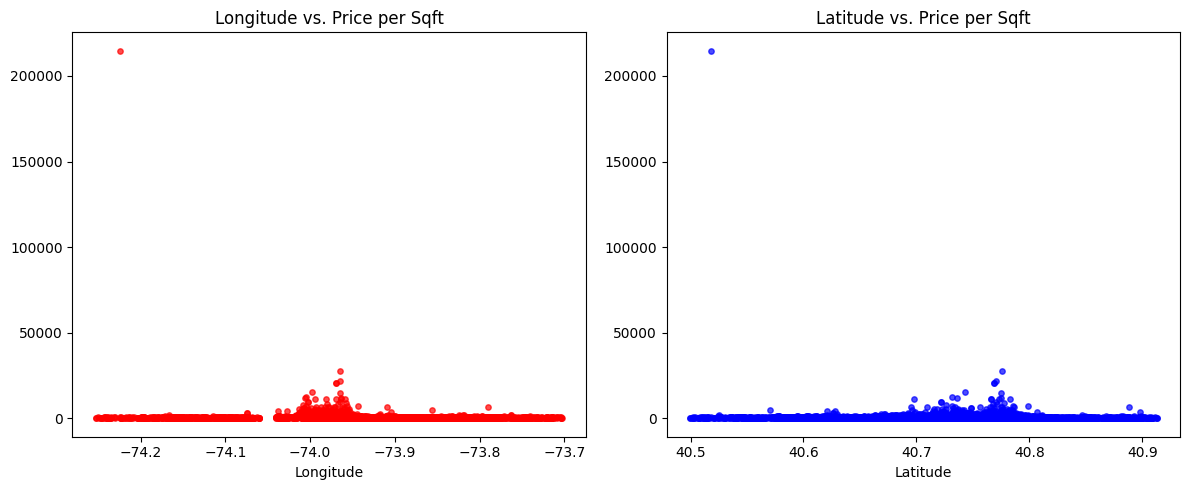

In [3]:
# Create a blank canvas with 2 side-by-side charts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Chart 1: Longitude vs Price per Sqft (Red)
ax1.scatter(data['LONGITUDE'], data['Price_per_Sqft'], color='red', s=15, alpha=0.7)
ax1.set_title('Longitude vs. Price per Sqft')
ax1.set_xlabel('Longitude')

# Chart 2: Latitude vs Price per Sqft (Blue)
ax2.scatter(data['LATITUDE'], data['Price_per_Sqft'], color='blue', s=15, alpha=0.7)
ax2.set_title('Latitude vs. Price per Sqft')
ax2.set_xlabel('Latitude')

plt.tight_layout()
plt.show()

# Step 4: Price Bins and Geographic Mapping
Finally, we use the `pd.qcut()` function to divide all the apartments into **5 equal Price Bins** (from 0 = Cheapest, to 4 = Most Expensive). 
We then map these bins using the exact Latitude and Longitude to see where the most expensive and cheapest apartments are clustered in New York.

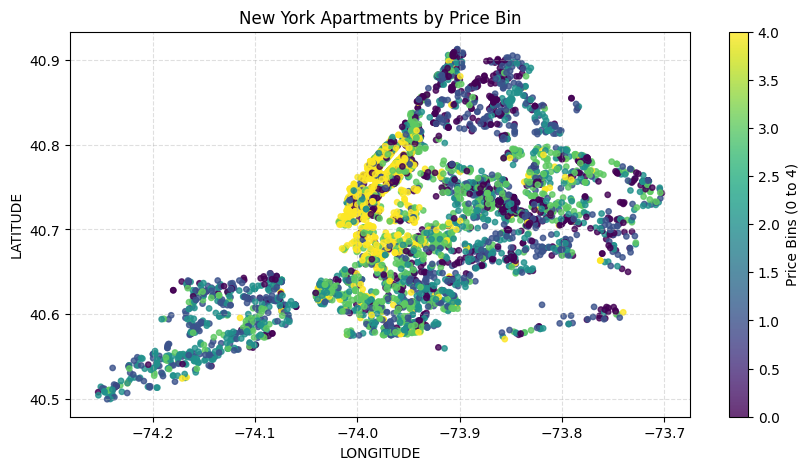

In [4]:
# Create the 5 Bins (Bin 0 to Bin 4)
data['Price_Bin'] = pd.qcut(data['Price_per_Sqft'], q=5, labels=[0, 1, 2, 3, 4])

plt.figure(figsize=(10, 5))
scatter_plot = plt.scatter(data['LONGITUDE'], data['LATITUDE'], 
                           c=data['Price_Bin'], cmap='viridis', s=15, alpha=0.8)

plt.title('New York Apartments by Price Bin')
plt.xlabel('LONGITUDE')
plt.ylabel('LATITUDE')
plt.colorbar(scatter_plot, label='Price Bins (0 to 4)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

In [ ]:
import folium

# Colour palette matching the viridis bins (0=cheapest → 4=most expensive)
bin_colors = {
    0: '#440154',  # dark purple  – cheapest
    1: '#31688e',  # blue
    2: '#35b779',  # green
    3: '#fde725',  # yellow
    4: '#ff0000',  # red          – most expensive
}

# Centre the map on New York City
nyc_map = folium.Map(location=[40.730610, -73.935242], zoom_start=11, tiles='OpenStreetMap')

# Plot every apartment as a small circle
for _, row in data.iterrows():
    bin_val = int(row['Price_Bin'])
    folium.CircleMarker(
        location=[row['LATITUDE'], row['LONGITUDE']],
        radius=4,
        color=bin_colors[bin_val],
        fill=True,
        fill_color=bin_colors[bin_val],
        fill_opacity=0.7,
        popup=f"Price Bin: {bin_val}<br>Price/Sqft: ${row['Price_per_Sqft']:.2f}"
    ).add_to(nyc_map)

# Add a simple legend
legend_html = """
<div style="position:fixed; bottom:40px; left:40px; z-index:1000;
            background:white; padding:10px; border-radius:8px;
            border:1px solid grey; font-size:13px;">
  <b>Price Bin</b><br>
  <span style="color:#440154;">&#9679;</span> Bin 0 – Cheapest<br>
  <span style="color:#31688e;">&#9679;</span> Bin 1<br>
  <span style="color:#35b779;">&#9679;</span> Bin 2<br>
  <span style="color:#fde725;">&#9679;</span> Bin 3<br>
  <span style="color:#ff0000;">&#9679;</span> Bin 4 – Most Expensive
</div>
"""
nyc_map.get_root().html.add_child(folium.Element(legend_html))

nyc_map